# Deep Learning-Based Classification of Balanced WCE Dataset
## Notebook 2: KVASIR v2 Dataset (Balanced)

**Objective:** Design, train, and evaluate deep learning models for gastrointestinal disease classification using the balanced KVASIR v2 dataset.
**Models:** EfficientNet-B0 | ResNet101V2 | InceptionV3

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetB0, ResNet101V2, InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
warnings.filterwarnings('ignore')

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
THRESHOLD = 200
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)
print("GPU:", tf.config.list_physical_devices('GPU'))

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Task 1: Dataset Exploration and Imbalance Analysis

Total images: 8000
Imbalance ratio: 1.0x


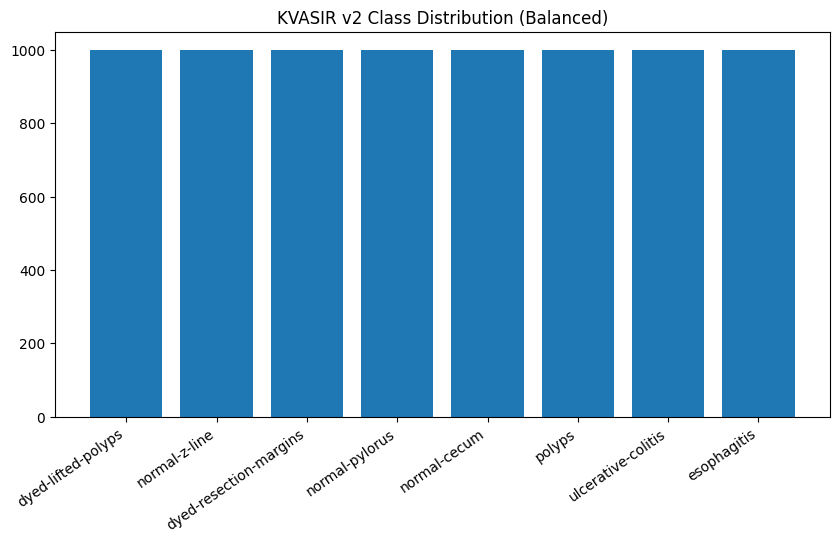

In [2]:
BASE_INPUT = '/kaggle/input/the-kvasir-dataset/kvasir-dataset-v2'
DATASET_DIR = None
for root, dirs, files in os.walk(BASE_INPUT):
    if list(dirs) and any(f.endswith(('.jpg','.png')) for f in os.listdir(os.path.join(root, dirs[0]))):
        DATASET_DIR = root; break

all_files, all_labels = [], []
for cname in os.listdir(DATASET_DIR):
    cpath = os.path.join(DATASET_DIR, cname)
    if os.path.isdir(cpath):
        for f in os.listdir(cpath):
            if f.endswith(('.jpg','.png')):
                all_files.append(os.path.join(cpath, f))
                all_labels.append(cname)

df_all = pd.DataFrame({'filepath': all_files, 'label': all_labels})
class_counts = df_all['label'].value_counts()

print(f"Total images: {len(df_all)}")
print(f"Imbalance ratio: {class_counts.max()/class_counts.min():.1f}x")
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(class_counts)), class_counts.values)
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(class_counts.index, rotation=35, ha='right')
plt.title('KVASIR v2 Class Distribution (Balanced)')
plt.show()

## Task 2: Under-Sampling (Majority Class Control)

Original size: 8000 | After US: 1600


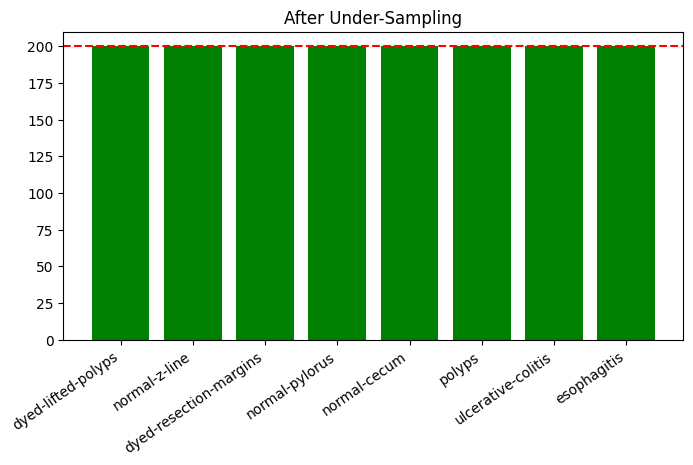

In [3]:
def undersample(df, threshold):
    dfs = []
    for label in df['label'].unique():
        group = df[df['label'] == label]
        dfs.append(group.sample(n=min(len(group), threshold), random_state=SEED))
    return pd.concat(dfs, ignore_index=True)

df_undersampled = undersample(df_all, THRESHOLD)
us_counts = df_undersampled['label'].value_counts()
print(f"Original size: {len(df_all)} | After US: {len(df_undersampled)}")
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(us_counts)), us_counts.values, color='green')
ax.set_xticks(range(len(us_counts)))
ax.set_xticklabels(us_counts.index, rotation=35, ha='right')
ax.axhline(y=THRESHOLD, color='red', linestyle='--')
plt.title('After Under-Sampling')
plt.show()

## Task 3: Data Augmentation-Based Over-Sampling

In [4]:
AUG_DIR = '/kaggle/working/aug_v2'
os.makedirs(AUG_DIR, exist_ok=True)
aug_datagen = ImageDataGenerator(
    horizontal_flip=True, rotation_range=20,
    width_shift_range=0.2, height_shift_range=0.2, zoom_range=0.2, fill_mode='nearest')

def augment_minority(df, threshold, aug_dir):
    new_rows = []
    for label in df['label'].unique():
        group = df[df['label'] == label]
        needed = threshold - len(group)
        if needed <= 0: continue
        cls_dir = os.path.join(aug_dir, label.replace(' ', '_'))
        os.makedirs(cls_dir, exist_ok=True)
        idx = 0
        while idx < needed:
            row = group.sample(1, random_state=SEED+idx).iloc[0]
            img = load_img(row['filepath'], target_size=(IMG_SIZE, IMG_SIZE))
            x = img_to_array(img).reshape((1,)+img_to_array(img).shape)
            for batch in aug_datagen.flow(x, batch_size=1):
                aug_path = os.path.join(cls_dir, f'aug_{idx}.jpg')
                tf.keras.utils.save_img(aug_path, batch[0].astype('uint8'))
                new_rows.append({'filepath': aug_path, 'label': label})
                idx += 1; break
            if idx >= needed: break
    return pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)

df_augmented = augment_minority(df_undersampled.copy(), THRESHOLD, AUG_DIR)
aug_counts = df_augmented['label'].value_counts()
print(aug_counts)

label
dyed-lifted-polyps        200
normal-z-line             200
dyed-resection-margins    200
normal-pylorus            200
normal-cecum              200
polyps                    200
ulcerative-colitis        200
esophagitis               200
Name: count, dtype: int64


## Task 4: Data Pre-Processing & Splits

In [5]:
df_tr_o, df_temp = train_test_split(df_all, test_size=0.3, random_state=SEED, stratify=df_all['label'])
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=SEED, stratify=df_temp['label'])

df_train_s1 = df_tr_o.copy()
df_train_s2 = undersample(df_tr_o, THRESHOLD)
AUG_S3 = '/kaggle/working/aug_v2_s3'
os.makedirs(AUG_S3, exist_ok=True)
df_train_s3 = augment_minority(undersample(df_tr_o, THRESHOLD), THRESHOLD, AUG_S3)

def make_generators(df_tr, df_v, df_te):
    tr_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        df_tr, x_col='filepath', y_col='label', target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=SEED)
    v_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        df_v, x_col='filepath', y_col='label', target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
    te_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        df_te, x_col='filepath', y_col='label', target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
    return tr_gen, v_gen, te_gen
NUM_CLASSES = len(df_all['label'].unique())

## Task 5 & 6: Models and Learning Rate Control

In [6]:
def build_model(model_name):
    shp = (IMG_SIZE, IMG_SIZE, 3)
    if model_name == 'EfficientNetB0': base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=shp)
    elif model_name == 'ResNet101V2': base = ResNet101V2(weights='imagenet', include_top=False, input_shape=shp)
    else: base = InceptionV3(weights='imagenet', include_top=False, input_shape=shp)
    
    for layer in base.layers[:int(len(base.layers)*0.7)]: layer.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inputs=base.input, outputs=out)

def cosine_decay(epoch, lr):
    return 1e-6 + 0.5*(0.001-1e-6)*(1+np.cos(np.pi*epoch/EPOCHS))

def get_callbacks():
    return [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        LearningRateScheduler(cosine_decay, verbose=0),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]

## Task 7: Training and Evaluation Grid (3x3)

In [7]:
settings = {'S1-Orig': df_train_s1, 'S2-US': df_train_s2, 'S3-US+Aug': df_train_s3}
MODELS = ['EfficientNetB0', 'ResNet101V2', 'InceptionV3']
results = []
histories = {}
predictions = {}

for s_name, df_tr in settings.items():
    for m_name in MODELS:
        print(f"\nTraining {m_name} on {s_name}...")
        tr_gen, v_gen, te_gen = make_generators(df_tr, df_val, df_test)
        model = build_model(m_name)
        model.compile(optimizer=keras.optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
        
        hist = model.fit(tr_gen, validation_data=v_gen, epochs=EPOCHS, callbacks=get_callbacks(), verbose=1)
        
        y_true = te_gen.classes
        y_pred = np.argmax(model.predict(te_gen, verbose=0), axis=1)
        
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        
        results.append({'Setting': s_name, 'Model': m_name, 'Acc': acc, 'Prec': prec, 'Rec': rec, 'F1': f1})
        histories[f"{s_name}_{m_name}"] = hist.history
        predictions[f"{s_name}_{m_name}"] = (y_true, y_pred, te_gen.class_indices)
        del model; tf.keras.backend.clear_session()

df_res = pd.DataFrame(results)
print("\nResults:")
print(df_res)
df_res.to_csv('kvasir_v2_results.csv', index=False)


Training EfficientNetB0 on S1-Orig...
Found 5600 validated image filenames belonging to 8 classes.
Found 1200 validated image filenames belonging to 8 classes.
Found 1200 validated image filenames belonging to 8 classes.
16705208/16705208 [==============================] - 0s 0us/step
Epoch 1/15


2026-03-24 09:43:00.077211: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


175/175 [==============================] - 156s 789ms/step - loss: 6.4321 - accuracy: 0.1661 - val_loss: 5.1339 - val_accuracy: 0.1250 - lr: 0.0010
Epoch 2/15
175/175 [==============================] - 72s 411ms/step - loss: 4.3220 - accuracy: 0.2725 - val_loss: 3.8679 - val_accuracy: 0.2275 - lr: 9.8908e-04
Epoch 3/15
175/175 [==============================] - 65s 374ms/step - loss: 3.0741 - accuracy: 0.3355 - val_loss: 3.1748 - val_accuracy: 0.3008 - lr: 9.5682e-04
Epoch 4/15
175/175 [==============================] - 66s 375ms/step - loss: 2.2740 - accuracy: 0.3920 - val_loss: 4.1681 - val_accuracy: 0.2783 - lr: 9.0460e-04
Epoch 5/15
175/175 [==============================] - 65s 371ms/step - loss: 1.9038 - accuracy: 0.4121 - val_loss: 4.6466 - val_accuracy: 0.1667 - lr: 8.3473e-04
Epoch 6/15
175/175 [==============================] - ETA: 0s - loss: 1.6354 - accuracy: 0.4523
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003751250042114407.
175/175 [=======================

2026-03-24 10:38:14.501853: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


50/50 [==============================] - 44s 573ms/step - loss: 7.4346 - accuracy: 0.1444 - val_loss: 5.9994 - val_accuracy: 0.2000 - lr: 0.0010
Epoch 2/15
50/50 [==============================] - 27s 535ms/step - loss: 6.4395 - accuracy: 0.2056 - val_loss: 5.6438 - val_accuracy: 0.1250 - lr: 9.8908e-04
Epoch 3/15
50/50 [==============================] - 27s 533ms/step - loss: 5.8177 - accuracy: 0.2206 - val_loss: 5.5979 - val_accuracy: 0.1250 - lr: 9.5682e-04
Epoch 4/15
50/50 [==============================] - 26s 526ms/step - loss: 5.1985 - accuracy: 0.2719 - val_loss: 5.4003 - val_accuracy: 0.1250 - lr: 9.0460e-04
Epoch 5/15
50/50 [==============================] - 27s 542ms/step - loss: 4.6625 - accuracy: 0.2881 - val_loss: 4.7971 - val_accuracy: 0.2325 - lr: 8.3473e-04
Epoch 6/15
50/50 [==============================] - 27s 535ms/step - loss: 4.2151 - accuracy: 0.3219 - val_loss: 5.0530 - val_accuracy: 0.1250 - lr: 7.5025e-04
Epoch 7/15
50/50 [==============================] - 27s

2026-03-24 11:00:52.763895: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


50/50 [==============================] - 44s 573ms/step - loss: 7.3863 - accuracy: 0.1250 - val_loss: 6.0092 - val_accuracy: 0.1250 - lr: 0.0010
Epoch 2/15
50/50 [==============================] - 28s 558ms/step - loss: 6.6382 - accuracy: 0.1700 - val_loss: 5.7190 - val_accuracy: 0.1250 - lr: 9.8908e-04
Epoch 3/15
50/50 [==============================] - 28s 559ms/step - loss: 6.0070 - accuracy: 0.2119 - val_loss: 5.2727 - val_accuracy: 0.1250 - lr: 9.5682e-04
Epoch 4/15
50/50 [==============================] - 29s 573ms/step - loss: 5.3367 - accuracy: 0.2562 - val_loss: 5.2574 - val_accuracy: 0.1250 - lr: 9.0460e-04
Epoch 5/15
50/50 [==============================] - 27s 547ms/step - loss: 4.7651 - accuracy: 0.2688 - val_loss: 5.3138 - val_accuracy: 0.1250 - lr: 8.3473e-04
Epoch 6/15
50/50 [==============================] - 27s 553ms/step - loss: 4.2930 - accuracy: 0.3050 - val_loss: 6.1850 - val_accuracy: 0.1250 - lr: 7.5025e-04
Epoch 7/15
50/50 [==============================] - ETA

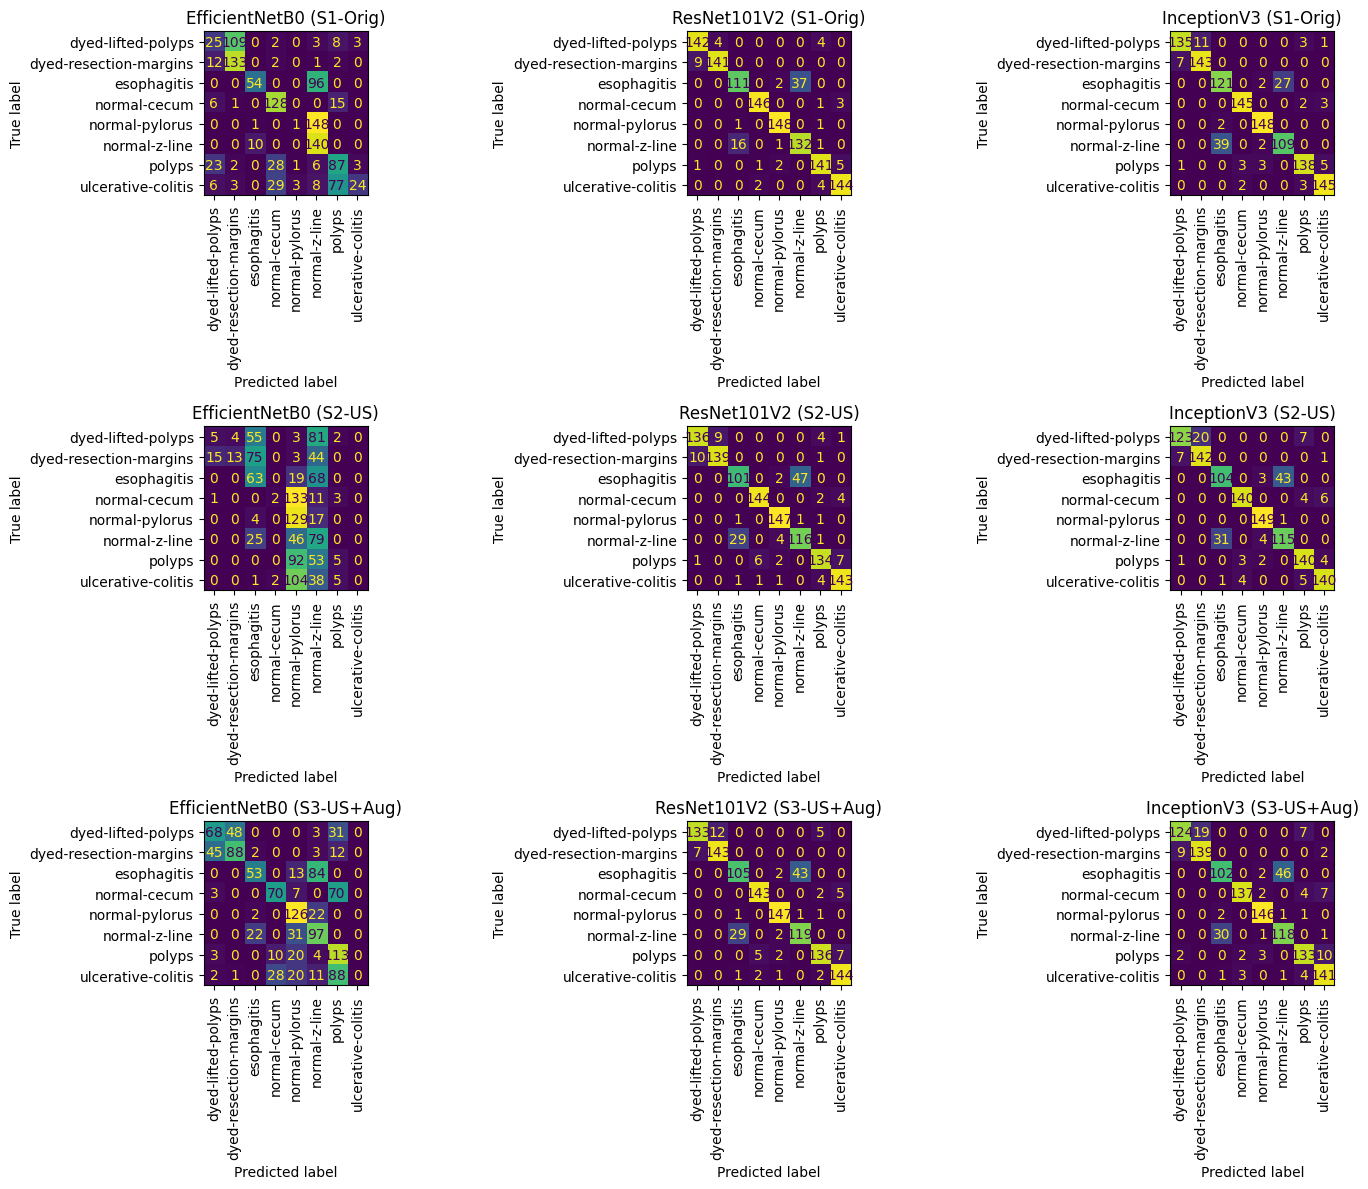

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, s_name in enumerate(settings.keys()):
    for j, m_name in enumerate(MODELS):
        y_true, y_pred, c_idx = predictions[f"{s_name}_{m_name}"]
        labels = sorted(c_idx, key=c_idx.get)
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=labels)
        disp.plot(ax=axes[i, j], xticks_rotation=90, colorbar=False)
        axes[i, j].set_title(f"{m_name} ({s_name})")
plt.tight_layout()
plt.show()

## Final Comparison (Imbalanced vs Balanced)

In [9]:
import os
capsule_csv = 'kvasir_capsule_results.csv'
if os.path.exists(capsule_csv):
    df_c = pd.read_csv(capsule_csv)
    df_c['Dataset'] = 'Imbalanced'
    df_v = df_res.copy()
    df_v['Dataset'] = 'Balanced'
    df_all_res = pd.concat([df_c, df_v], ignore_index=True)
    print("\n=== FINAL COMPARISON ===")
    print(df_all_res)
    df_all_res.to_csv('final_comparison_results.csv', index=False)
else:
    print("Imbalanced results.csv not found, so no comparison could be made.")

Imbalanced results.csv not found, so no comparison could be made.
